# Conventional CNN with ROI Extraction for PCB Defect Detection

This notebook implements a conventional Convolutional Neural Network (CNN) with Region of Interest (ROI) extraction for detecting and classifying defects in Printed Circuit Boards (PCBs). The model extracts focused regions around defects before training to improve classification accuracy.

## Dataset
- **Source**: PCB defect detection dataset from Kaggle
- **Format**: JPG images with corresponding JSON annotation files
- **Labels**: Various defect types (excluding 'good' and 'no_good' samples)
- **Location**: `../dataset/Labeled/`

## Key Enhancement
- **ROI Extraction**: Automatically extracts regions of interest around defects from the full images
- **Focused Training**: Trains on cropped regions containing the defects rather than full images

In [20]:
# Standard library imports
import os
import json
import math

# Data manipulation and visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.image as mpimg

# Image processing
import cv2

# Machine learning libraries
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

# TensorFlow and Keras
import tensorflow as tf
from tensorflow.keras import layers, models

# Data augmentation
import albumentations as A
from albumentations.pytorch.transforms import ToTensorV2

print("All libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

All libraries imported successfully!
TensorFlow version: 2.18.0
GPU available: []


In [21]:
def create_dummy_image():
    """
    Create a dummy placeholder image for visualization when actual images are not available.
    
    Returns:
        numpy.ndarray: RGB image array (100x100x3) with white background
    """
    dummy_image_path = "../dataset/nosample.png" 
    if os.path.exists(dummy_image_path):
        return mpimg.imread(dummy_image_path)
    else:
        print(f"Warning: '{dummy_image_path}' not found. Using a blank dummy image.")
        return np.ones((100, 100, 3), dtype=np.uint8) * 255

## Data Loading and Preparation

The following section loads the labeled PCB images and their corresponding annotations from JSON files.

In [22]:
# Define the directory containing the labeled dataset
dataset_dir = r'C:\Users\david\Desktop\project\dataset\Labeled'
print(f"Loading data from: {dataset_dir}")

# Initialize list to store image-label pairs
data = []

# Process all JPG files in the directory
for filename in os.listdir(dataset_dir):
    if filename.lower().endswith('.jpg'):
        image_path = os.path.join(dataset_dir, filename)
        json_path = image_path.replace('.jpg', '.json')
        
        label = None
        # Extract label from corresponding JSON file
        if os.path.exists(json_path):
            try:
                with open(json_path, 'r') as f:
                    content = json.load(f)
                    shapes = content.get('shapes', [])
                    if shapes and isinstance(shapes, list):
                        label = shapes[0].get('label')
            except Exception as e:
                print(f"Error reading {json_path}: {e}")
        
        data.append({'filename': image_path, 'label': label})

# Create DataFrame and display basic information
df = pd.DataFrame(data)
print(f"\nDataset loaded successfully!")
print(f"Total samples: {len(df)}")
print(f"Samples with labels: {df['label'].notna().sum()}")
print(f"Unique labels: {df['label'].unique()}")

# Display dataset info and first few rows
print("\n" + "="*50)
print("DATASET INFORMATION")
print("="*50)
df.info()
print("\n" + "="*50)
print("FIRST 5 SAMPLES")
print("="*50)
display(df.head())

Loading data from: C:\Users\david\Desktop\project\dataset\Labeled

Dataset loaded successfully!
Total samples: 428
Samples with labels: 428
Unique labels: ['no_good' 'good' 'exc_solder' 'poor_solder' 'spike']

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 428 entries, 0 to 427
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   filename  428 non-null    object
 1   label     428 non-null    object
dtypes: object(2)
memory usage: 6.8+ KB

FIRST 5 SAMPLES


,filename,label
0,C:\Users\david\Desktop\project\dataset\Labeled...,no_good
1,C:\Users\david\Desktop\project\dataset\Labeled...,no_good
2,C:\Users\david\Desktop\project\dataset\Labeled...,no_good
3,C:\Users\david\Desktop\project\dataset\Labeled...,no_good
4,C:\Users\david\Desktop\project\dataset\Labeled...,good


## ROI Extraction Function

This section defines the Region of Interest (ROI) extraction function that crops focused regions around defects from the full images, improving the model's ability to focus on relevant features.

In [23]:
def extract_roi(image_path, json_path):
    """
    Extracts a region of interest (ROI) that includes the entire component and both solder joints.
    Ensures the component is centered and fully visible with adequate padding.
    
    Args:
        image_path (str): Path to the input image
        json_path (str): Path to the corresponding JSON annotation file
        
    Returns:
        numpy.ndarray: Cropped ROI image
    """
    try:
        # Read the image
        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        with open(json_path, 'r') as f:
            content = json.load(f)
            shapes = content.get('shapes', [])
            
            if shapes and isinstance(shapes, list):
                # Get all points from all shapes
                all_points = []
                for shape in shapes:
                    points = shape.get('points', [])
                    if points:
                        all_points.extend(points)
                
                if all_points:
                    # Convert points to numpy array
                    points = np.array(all_points, dtype=np.int32)
                    
                    # Get bounding box
                    x, y, w, h = cv2.boundingRect(points)
                    
                    # Calculate center
                    center_x = x + w // 2
                    center_y = y + h // 2
                    
                    # Make ROI wider to ensure both solder joints are visible
                    # Width is 3x the component width or height (whichever is larger)
                    size_w = max(w, h) * 3
                    # Height is 2x the component height
                    size_h = h * 2
                    
                    # Calculate crop coordinates with padding
                    x1 = max(0, center_x - size_w // 2)
                    y1 = max(0, center_y - size_h // 2)
                    x2 = min(image.shape[1], x1 + size_w)
                    y2 = min(image.shape[0], y1 + size_h)
                    
                    # Adjust coordinates if they hit image boundaries
                    if x1 == 0:
                        x2 = min(image.shape[1], size_w)
                    if y1 == 0:
                        y2 = min(image.shape[0], size_h)
                    if x2 == image.shape[1]:
                        x1 = max(0, x2 - size_w)
                    if y2 == image.shape[0]:
                        y1 = max(0, y2 - size_h)
                    
                    # Extract ROI
                    roi = image[y1:y2, x1:x2]
                    return roi
                    
            print(f"No valid shapes found in {json_path}")
            return image
            
    except Exception as e:
        print(f"Error extracting ROI from {image_path}: {e}")
        return image

## Data Preprocessing and Augmentation

This section prepares the data for training by filtering relevant classes, splitting into train/validation sets, and setting up data augmentation pipelines with ROI extraction.

In [24]:
# Filter out 'no_good' samples to focus on specific defect types
df_filtered = df[~df['label'].isin(['no_good'])].copy()
print(f"Samples after filtering: {len(df_filtered)}")
print(f"Remaining labels: {df_filtered['label'].value_counts()}")

# Configuration parameters
TARGET_SIZE = (224, 224)
BATCH_SIZE = 32
TEST_SIZE = 0.2
RANDOM_STATE = 42

print(f"\nConfiguration:")
print(f"- Target image size: {TARGET_SIZE}")
print(f"- Batch size: {BATCH_SIZE}")
print(f"- Validation split: {TEST_SIZE}")

# Split data into training and validation sets
train_df, val_df = train_test_split(
    df_filtered, 
    test_size=TEST_SIZE, 
    stratify=df_filtered['label'], 
    random_state=RANDOM_STATE
)

print(f"\nData split:")
print(f"- Training samples: {len(train_df)}")
print(f"- Validation samples: {len(val_df)}")

# Create class indices mapping
class_indices = {label: idx for idx, label in enumerate(train_df['label'].unique())}
num_classes = len(class_indices)
print(f"\nClass mapping: {class_indices}")
print(f"Number of classes: {num_classes}")

# Define training data augmentation pipeline using Albumentations
train_augmentation_pipeline = A.Compose([
    A.Resize(TARGET_SIZE[0], TARGET_SIZE[1]),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
    A.GaussNoise(p=0.2),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),  # ImageNet normalization
    ToTensorV2(),
])

# Define validation pipeline without augmentations
val_augmentation_pipeline = A.Compose([
    A.Resize(TARGET_SIZE[0], TARGET_SIZE[1]),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),  # ImageNet normalization
    ToTensorV2(),
])

def create_data_generator_with_roi(df, batch_size, augmentations, target_size, class_indices):
    """
    Custom data generator with ROI extraction using Albumentations for image augmentation.
    
    Args:
        df: DataFrame containing image paths and labels
        batch_size: Number of samples per batch
        augmentations: Albumentations pipeline
        target_size: Target image dimensions
        class_indices: Dictionary mapping labels to indices
        
    Yields:
        tuple: (batch of images, batch of one-hot encoded labels)
    """
    while True:
        for i in range(0, len(df), batch_size):
            batch_df = df.iloc[i:i+batch_size]
            images = []
            labels = []
            
            for _, row in batch_df.iterrows():
                # Extract ROI from image
                image_path = row['filename']
                json_path = image_path.replace('.jpg', '.json')
                roi = extract_roi(image_path, json_path)
                
                # Apply augmentations
                augmented = augmentations(image=roi)
                image = augmented['image']
                
                # Convert to channels-last format if needed
                if image.shape[0] == 3:
                    image = np.transpose(image, (1, 2, 0))
                
                images.append(image)
                
                # Convert label to one-hot encoding
                label_idx = class_indices[row['label']]
                one_hot_label = tf.keras.utils.to_categorical(label_idx, num_classes=len(class_indices))
                labels.append(one_hot_label)
            
            yield np.array(images), np.array(labels)

# Create data generators
train_generator = create_data_generator_with_roi(train_df, BATCH_SIZE, train_augmentation_pipeline, TARGET_SIZE, class_indices)
val_generator = create_data_generator_with_roi(val_df, BATCH_SIZE, val_augmentation_pipeline, TARGET_SIZE, class_indices)

print("\nData generators with ROI extraction created successfully!")

Samples after filtering: 312
Remaining labels: label
good           162
exc_solder      81
spike           38
poor_solder     31
Name: count, dtype: int64

Configuration:
- Target image size: (224, 224)
- Batch size: 32
- Validation split: 0.2

Data split:
- Training samples: 249
- Validation samples: 63

Class mapping: {'good': 0, 'exc_solder': 1, 'spike': 2, 'poor_solder': 3}
Number of classes: 4

Data generators with ROI extraction created successfully!


In [ ]:
model = models.Sequential([
    # First convolutional block
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(TARGET_SIZE[0], TARGET_SIZE[1], 3)),
    layers.MaxPooling2D(2, 2),
    
    # Second convolutional block
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    
    # Dense layers
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),  # Add dropout for regularization
    layers.Dense(num_classes, activation='softmax')
])

# Compile the model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Display model architecture
print("Model Architecture:")
print("="*50)
model.summary()

# Training configuration
EPOCHS = 20
steps_per_epoch = math.ceil(len(train_df) / BATCH_SIZE)
validation_steps = math.ceil(len(val_df) / BATCH_SIZE)

print(f"\nTraining Configuration:")
print(f"- Epochs: {EPOCHS}")
print(f"- Steps per epoch: {steps_per_epoch}")
print(f"- Validation steps: {validation_steps}")

# Train the model
print(f"\nStarting training...")
print("="*50)

history = model.fit(
    train_generator,
    steps_per_epoch=steps_per_epoch,
    epochs=EPOCHS,
    validation_data=val_generator,
    validation_steps=validation_steps,
    verbose=1
)

print("\nTraining completed!")

Model Architecture:


c:\Users\david\miniconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 186624)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │    23,888,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,907,908 (91.20 MB)

 Trainable params: 23,907,908 (91.20 MB)

 Non-trainable params: 0 (0.00 B)


Training Configuration:
- Epochs: 20
- Steps per epoch: 8
- Validation steps: 2

Starting training...
Epoch 1/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - accuracy: 0.3969 - loss: 20.6853 - val_accuracy: 0.3175 - val_loss: 1.3231
Epoch 2/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.3690 - loss: 1.9789 - val_accuracy: 0.5714 - val_loss: 1.2613
Epoch 3/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.5976 - loss: 1.2058 - val_accuracy: 0.5397 - val_loss: 0.9891
Epoch 4/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.5993 - loss: 1.0368 - val_accuracy: 0.5397 - val_loss: 0.9484
Epoch 5/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.5759 - loss: 0.9597 - val_accuracy: 0.6032 - val_loss: 0.9359
Epoch 6/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.6078 - loss: 0.8529 - val_accuracy: 0.6032 - val_loss: 0.9248
Epoch 7/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.5977 - loss: 0.8951 - val_accuracy: 0.6032 - val_loss: 0.9039
Epoch 8/20
8/8 ━━━━━━━━━━━━━


Model saved to: ../model/conventional_cnn_roi.h5


## Training History Visualization

Visualizing the training and validation accuracy/loss curves to assess model performance.

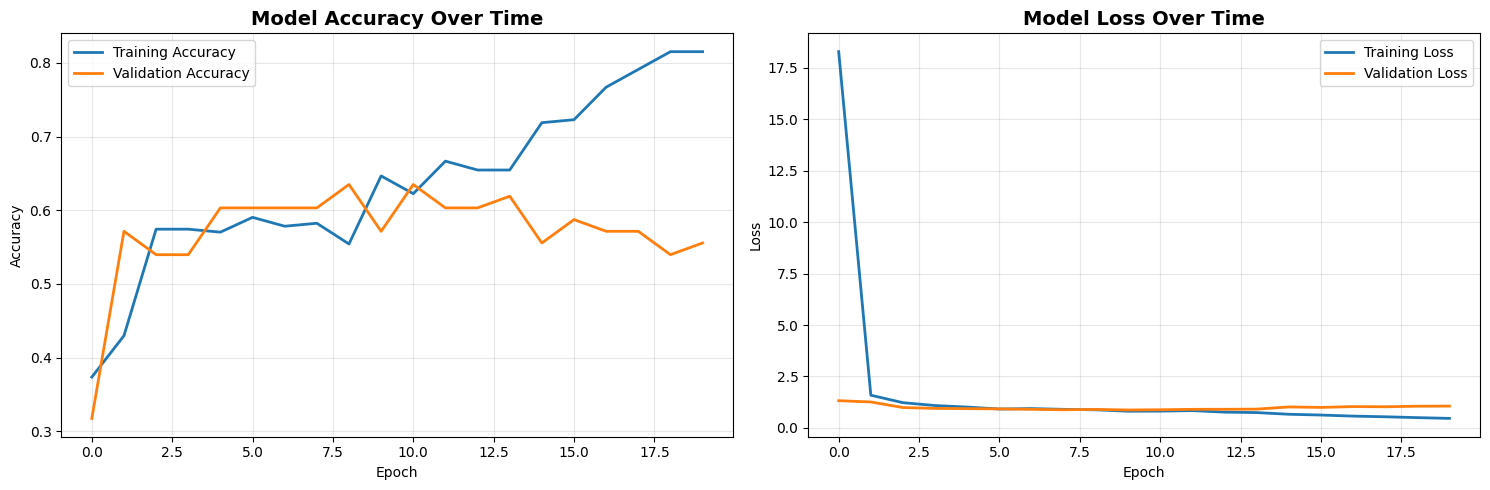


Final Training Results:
- Training Accuracy: 0.8153
- Validation Accuracy: 0.5556
- Training Loss: 0.4630
- Validation Loss: 1.0601


In [26]:
import matplotlib.pyplot as plt

# Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Accuracy plot
ax1.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
ax1.set_title('Model Accuracy Over Time', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Loss plot
ax2.plot(history.history['loss'], label='Training Loss', linewidth=2)
ax2.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
ax2.set_title('Model Loss Over Time', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print final training metrics
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]
final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]

print(f"\nFinal Training Results:")
print(f"- Training Accuracy: {final_train_acc:.4f}")
print(f"- Validation Accuracy: {final_val_acc:.4f}")
print(f"- Training Loss: {final_train_loss:.4f}")
print(f"- Validation Loss: {final_val_loss:.4f}")

# Evaluation

## Model Evaluation and Analysis

Comprehensive evaluation of the trained model including classification metrics, confusion matrix, and error analysis using ROI-extracted images.

Generating predictions on validation set...


1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/stepWARNING:tensorflow:6 out of the last 6 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x0000023475CD59E0> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
Predictions completed for 63 samples

CLASSIFICATION REPORT
              precision    recall  f1-score   support

        good       0.68      0.79      0.73        33
  exc_solder       0.35      0.44      0.39        16
       spike       0.00      0.00      0.00         8
 poor_solder       0.67      0.33      0.44         6

    accuracy                           0.56        63
   macro avg       0.43      0.39      0.39        63
weighted avg       0.51      0.56      0.52        63



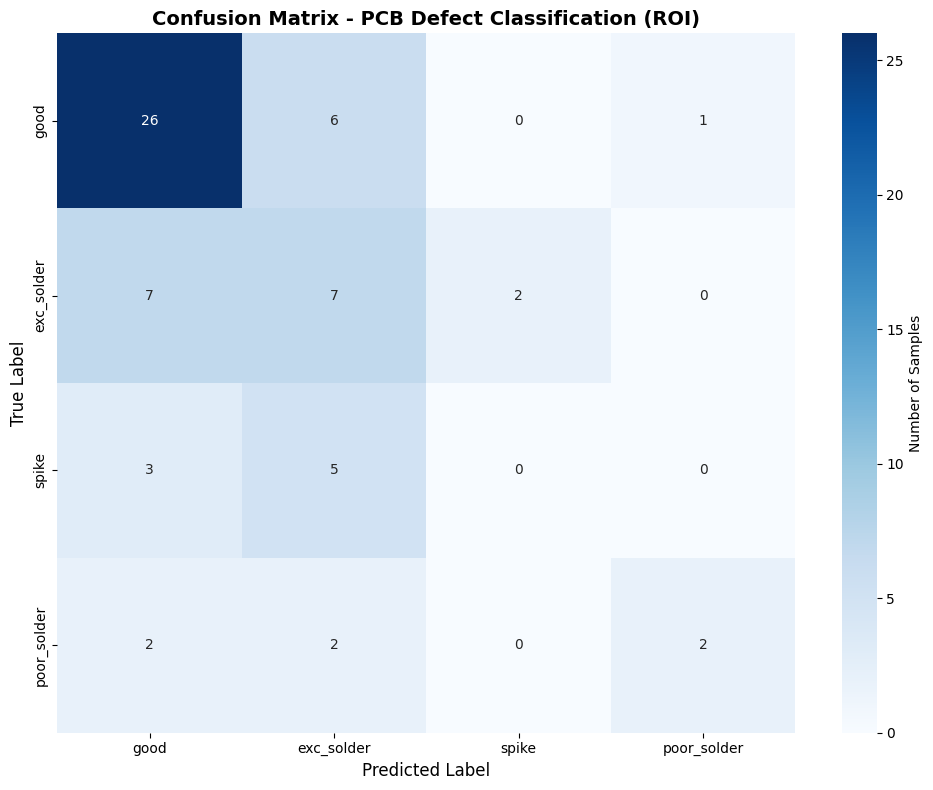


OVERALL PERFORMANCE METRICS
Accuracy:  0.5556
Precision: 0.5108
Recall:    0.5556
F1-Score:  0.5247

Creating error analysis visualization...


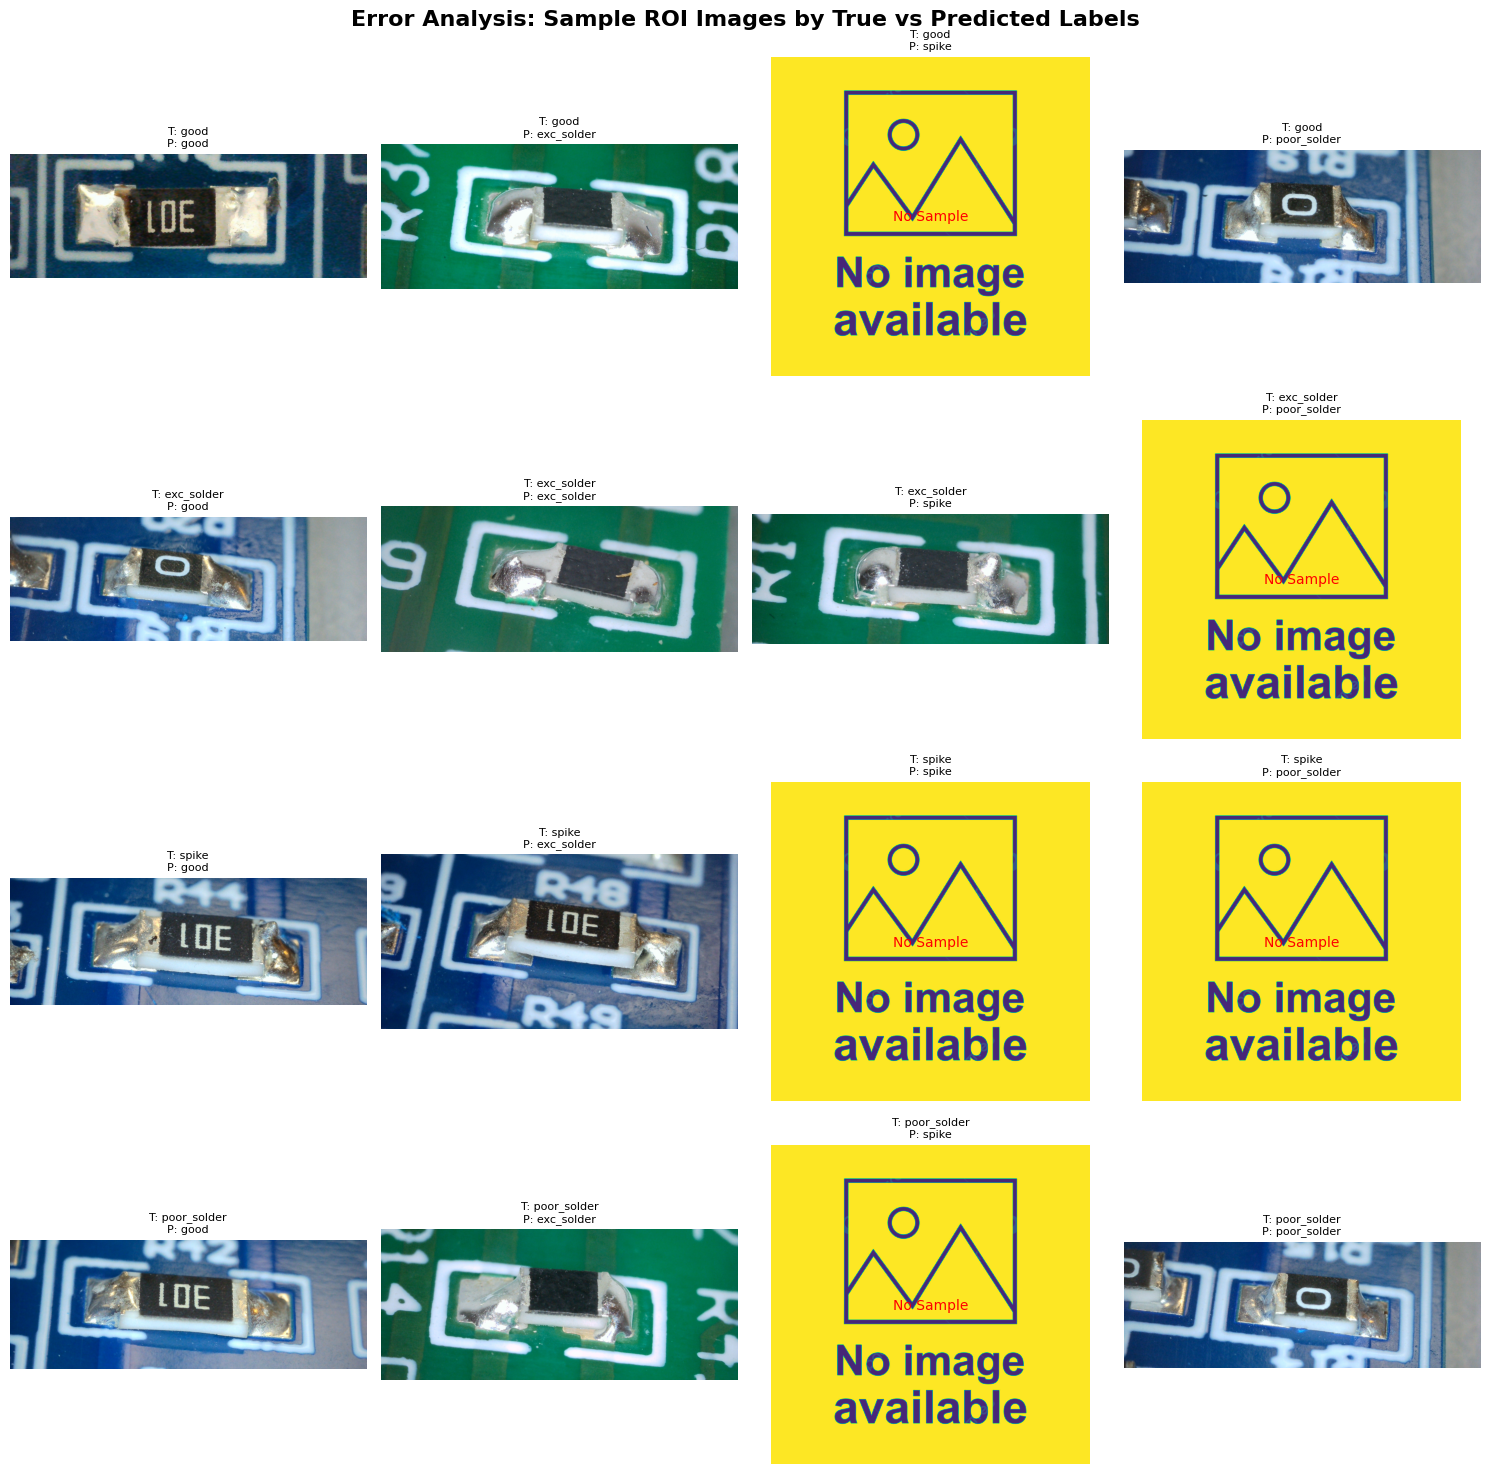

Evaluation completed!


In [27]:
# Generate predictions on validation set
print("Generating predictions on validation set...")
val_steps = math.ceil(len(val_df) / BATCH_SIZE)
predictions = model.predict(val_generator, steps=val_steps, verbose=1)
predicted_classes = np.argmax(predictions, axis=1)

# Prepare ground truth labels
true_classes = val_df['label'].map(class_indices).values
class_labels = list(class_indices.keys())

print(f"Predictions completed for {len(predicted_classes)} samples")

# Generate and display classification report
print("\n" + "="*70)
print("CLASSIFICATION REPORT")
print("="*70)
report = classification_report(true_classes, predicted_classes, target_names=class_labels)
print(report)

# Create and display confusion matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(true_classes, predicted_classes)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=class_labels, yticklabels=class_labels,
            cbar_kws={'label': 'Number of Samples'})
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.title("Confusion Matrix - PCB Defect Classification (ROI)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Calculate and display additional metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(true_classes, predicted_classes)
precision = precision_score(true_classes, predicted_classes, average='weighted')
recall = recall_score(true_classes, predicted_classes, average='weighted')
f1 = f1_score(true_classes, predicted_classes, average='weighted')

print(f"\n" + "="*50)
print("OVERALL PERFORMANCE METRICS")
print("="*50)
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")

# Error Analysis: Visual inspection of predictions
print(f"\nCreating error analysis visualization...")
fig, axes = plt.subplots(len(class_labels), len(class_labels), figsize=(15, 15))
fig.suptitle('Error Analysis: Sample ROI Images by True vs Predicted Labels', fontsize=16, fontweight='bold')

for true_idx, true_label in enumerate(class_labels):
    for pred_idx, pred_label in enumerate(class_labels):
        # Find samples for this true/predicted combination
        indices = np.where((true_classes == true_idx) & (predicted_classes == pred_idx))[0]
        
        if len(indices) > 0:
            # Use the first sample found
            sample_idx = indices[0]
            image_path = val_df['filename'].iloc[sample_idx]
            json_path = image_path.replace('.jpg', '.json')
            
            # Load and display ROI image
            if os.path.exists(image_path):
                roi_image = extract_roi(image_path, json_path)
            else:
                roi_image = create_dummy_image()
        else:
            # No sample exists for this combination
            roi_image = create_dummy_image()
        
        # Plot the image
        ax = axes[true_idx, pred_idx]
        ax.imshow(roi_image)
        ax.set_title(f"T: {true_label}\nP: {pred_label}", fontsize=8)
        if len(indices) == 0:
            ax.text(0.5, 0.5, "No Sample", transform=ax.transAxes, 
                   ha='center', va='center', fontsize=10, color='red')
        ax.axis('off')

plt.tight_layout()
plt.show()

print("Evaluation completed!")